# CycleSense

# Notebook 06: Cycle Peak Prediction (Classification)

## Objective

Predict whether a menstrual cycle contains a fertility peak using supervised machine learning.

This notebook compares multiple classification algorithms using a reproducible preprocessing and evaluation pipeline.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

In [4]:
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

In [5]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [7]:
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

In [8]:
from src.config import (
    PROCESSED_DATA_DIR,
    MODEL_DIR
)

from src.utils import save_model

In [9]:
X = pd.read_csv(
    PROCESSED_DATA_DIR / "X_peak.csv"
)

y = pd.read_csv(
    PROCESSED_DATA_DIR / "y_peak.csv"
).squeeze()

print(X.shape)
print(y.shape)

(1653, 77)
(1653,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print(X_train.shape)

(1322, 77)


In [11]:
selector = SelectKBest(

    score_func=mutual_info_classif,

    k=20

)

selector.fit(X_train, y_train)

,score_func,<function mut...0023EE4F2D1B0>
,k,20


In [12]:
selected_features = X_train.columns[
    selector.get_support()
]

selected_features

Index(['Group', 'EstimatedDayofOvulation', 'LengthofLutealPhase',
       'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak',
       'TotalNumberofPeakDays', 'TotalDaysofFertility',
       'TotalFertilityFormula', 'MensesScoreDayTen',
       'IntercourseInFertileWindow', 'Religion', 'Height', 'Abortions',
       'LivingkidsM', 'MedvitsM', 'Breastfeeding', 'Nextpreg', 'NextpregM',
       'SpousesameM'],
      dtype='object')

In [13]:
X_train = X_train[selected_features]

X_test = X_test[selected_features]

In [14]:
preprocessor = Pipeline([

    ("imputer", SimpleImputer(strategy="median")),

    ("scaler", StandardScaler())

])

In [15]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42)

}

In [16]:
results = []

In [18]:
for name, model in models.items():

    pipeline = Pipeline([

        ("preprocessing", preprocessor),

        ("model", model)

    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    probabilities = pipeline.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    roc = roc_auc_score(
        y_test,
        probabilities
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc

    ])

In [19]:
results = pd.DataFrame(

    results,

    columns=[

        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"

    ]

)

results.sort_values(
    "F1",
    ascending=False

)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.993958,0.996689,0.996689,0.996689,0.999429
4,Logistic Regression,0.993958,0.996689,0.996689,0.996689,0.999429
6,Gradient Boosting,0.990937,0.996678,0.993377,0.995025,0.995775
2,Gradient Boosting,0.990937,0.996678,0.993377,0.995025,0.995775
7,Extra Trees,0.978852,0.993311,0.983444,0.988353,0.989895
3,Extra Trees,0.978852,0.993311,0.983444,0.988353,0.989895
1,Random Forest,0.978852,0.996633,0.980132,0.988314,0.999201
5,Random Forest,0.978852,0.996633,0.980132,0.988314,0.999201


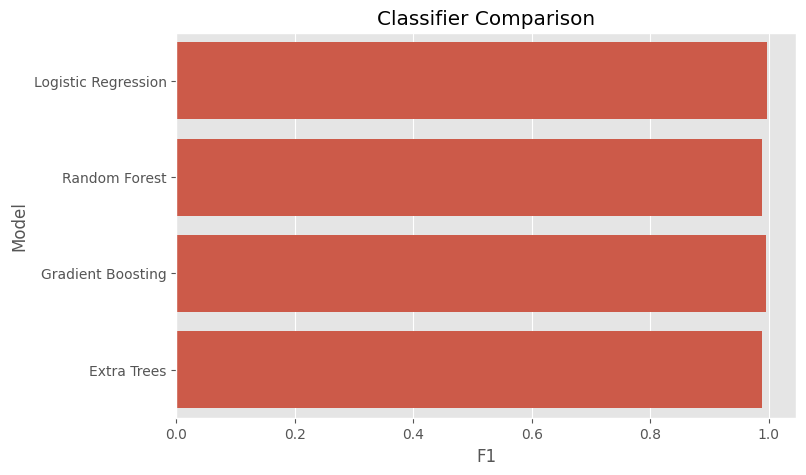

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=results,

    x="F1",

    y="Model"

)

plt.title("Classifier Comparison")

plt.show()

In [21]:
best_model_name = results.sort_values(

    "F1",

    ascending=False

).iloc[0]["Model"]

best_model_name

'Logistic Regression'

In [22]:
best_pipeline = Pipeline([

    ("preprocessing", preprocessor),

    ("model", models[best_model_name])

])

best_pipeline.fit(

    X_train,

    y_train

)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None


In [23]:
predictions = best_pipeline.predict(X_test)

print(classification_report(

    y_test,

    predictions

))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        29
           1       1.00      1.00      1.00       302

    accuracy                           0.99       331
   macro avg       0.98      0.98      0.98       331
weighted avg       0.99      0.99      0.99       331



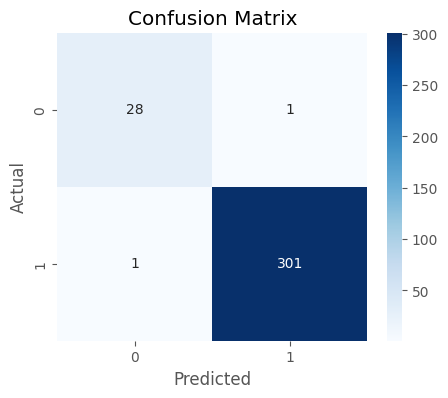

In [24]:
cm = confusion_matrix(

    y_test,

    predictions

)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [25]:
save_model(

    best_pipeline,

    MODEL_DIR / "best_peak_classifier.pkl"

)

print("Best classifier saved successfully.")

Best classifier saved successfully.


In [26]:
from src.config import REPORT_DIR

REPORT_DIR.mkdir(exist_ok=True)

results.to_csv(
    REPORT_DIR / "classification_results.csv",
    index=False
)

print("Classification results saved.")

Classification results saved.


# Conclusions

- Multiple classification algorithms were evaluated.
- Features were selected using Mutual Information.
- Models were compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- The best-performing classifier was saved for future inference.